### Velocity density map

This code plots the velocity density map (Ω vs U) for the three motility states of swimming Didinium nasutum. 

**Input:**

*main_folder*: Path to folder containing the analyzed trajectories. 

*tracks_info*: The name of the folders containing individual trajectory files and the corresponding pixel size of the timelapse

**Output:**

The velocity density map generated using kernel density estimates. 

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgb
from matplotlib.patches import Patch


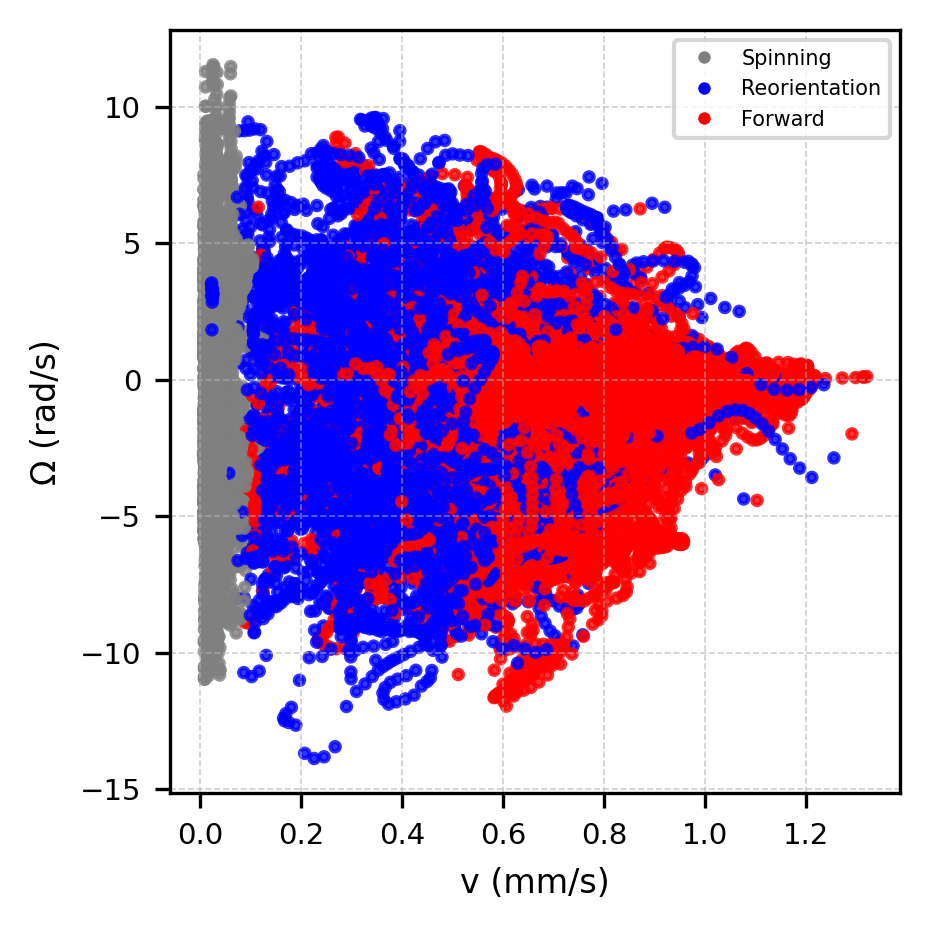

In [ ]:
### Input paths
main_folder   = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
tracks_info = [
    ("track_02", 68.375),
    ("track_01", 67.5),
    ("track_03", 67.5),
    ("track_04", 67.5),
    ("track_05", 68.89),
]

### Definition of color code for each state
color_spinning  =  'gray'
color_reorient = 'blue'
color_forward   = 'red'

### Reading the input and storing in arrays
all_speeds = []
all_ang_velocities = []
all_colors = []

for track_name, px_mm in tracks_info:
    analyzed_path = os.path.join(main_folder, track_name)
    file_path = os.path.join(analyzed_path, "scatter_data_velocity_map.npz")

    try:
        data = np.load(file_path)

        speed = data['speed']
        ang_velocity = data['ang_velocity']
 
        colors = np.full(len(speed), 'k', dtype=object)
        colors[data['rotation_indices']] = color_spinning
        colors[data['switching_indices']] = color_reorient
        colors[data['forward_indices']] = color_forward

        subset_indices = np.arange(len(speed))
        subset_colors = colors[subset_indices]
        classified_mask = subset_colors != 'k'

        all_speeds.extend(speed[subset_indices][classified_mask])
        all_ang_velocities.extend(ang_velocity[subset_indices][classified_mask])
        all_colors.extend(subset_colors[classified_mask])

    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error in {track_name}: {e}")

all_speeds = np.array(all_speeds)
all_ang_velocities = np.array(all_ang_velocities)
all_colors = np.array(all_colors, dtype=object)

### Plotting all combined classified points:
plt.figure(dpi=300, figsize=(3.2, 3.2))
plt.scatter(
    all_speeds, 
    all_ang_velocities, 
    c=all_colors, 
    s=5, 
    alpha=0.8
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Spinning',
           markerfacecolor=color_spinning, markersize=4),
    Line2D([0], [0], marker='o', color='w', label='Reorientation',
           markerfacecolor=color_reorient, markersize=4),
    Line2D([0], [0], marker='o', color='w', label='Forward',
           markerfacecolor=color_forward, markersize=4),
]

plt.legend(handles=legend_elements, loc='upper right', fontsize=5)
plt.xlabel('v (mm/s)', fontsize=8)
plt.ylabel('\u03A9 (rad/s)', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.tight_layout()
plt.show()

In [3]:
### Masking the states
mask_spinning = all_colors == color_spinning
mask_reorient = all_colors == color_reorient
mask_forward = all_colors == color_forward

In [4]:
### Creating the grid
finite_mask_all = np.isfinite(all_speeds) & np.isfinite(all_ang_velocities)
filtered_speeds = all_speeds[finite_mask_all]
filtered_ang_velocities = all_ang_velocities[finite_mask_all]

xmin, xmax = filtered_speeds.min(), filtered_speeds.max()
ymin, ymax = filtered_ang_velocities.min(), filtered_ang_velocities.max()

X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([X.ravel(), Y.ravel()])


In [5]:
### Computation of density map
def compute_density_contour_data(mask):
    subset_speeds = all_speeds[mask]
    subset_ang_velocities = all_ang_velocities[mask]

    finite_mask = np.isfinite(subset_speeds) & np.isfinite(subset_ang_velocities)
    subset_speeds = subset_speeds[finite_mask]
    subset_ang_velocities = subset_ang_velocities[finite_mask]

    if len(subset_speeds) < 10:
        return None

    values = np.vstack([subset_speeds, subset_ang_velocities])
    kernel = gaussian_kde(values)
    Z = np.reshape(kernel(positions).T, X.shape)
    return Z, kernel
        
Z_spinning, kernel_spinning  = compute_density_contour_data(mask_spinning)
Z_reorient, kernel_reorient  = compute_density_contour_data(mask_reorient)
Z_forward, kernel_forward  = compute_density_contour_data(mask_forward)

In [6]:
### Definition of plotting function
def plot_filled_kde(Z, min_percentile, base_color, label=None):
    if Z is None:
        return
    flat_Z = Z.ravel()

    min_level = np.percentile(flat_Z, min_percentile)
    max_level = flat_Z.max()

    levels = np.linspace(min_level, max_level, 100)  # More levels = smoother transition

    # Creating colormap and contours
    rgba = plt.matplotlib.colors.to_rgba(base_color)
    cmap = LinearSegmentedColormap.from_list(
        f"fade_{base_color}",
        [
            (0, (*rgba[:3], 0.1)),   
            (1, (*rgba[:3], 1.0))   
        ]
    )
    norm = Normalize(vmin=min_level, vmax=max_level)

    plt.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=norm, antialiased=False)
    contour_levels = np.percentile(flat_Z, [85, 90, 95, 99])  

    base_rgb = np.array(to_rgb(base_color))  
    darker_rgb = base_rgb * 0.6              

    # Plotting
    cs = plt.contour(X, Y, Z, levels=contour_levels, colors=[darker_rgb], linewidths=0.4, linestyles='dashed') # colors=[base_color]

    percentile_labels = ['85%', '90%', '95%', '99%']
    fmt = {level: label for level, label in zip(contour_levels, percentile_labels)}

    texts = plt.clabel(cs, fmt=fmt, inline=True, fontsize=4)
    for txt in texts:
        txt.set_rotation(0)

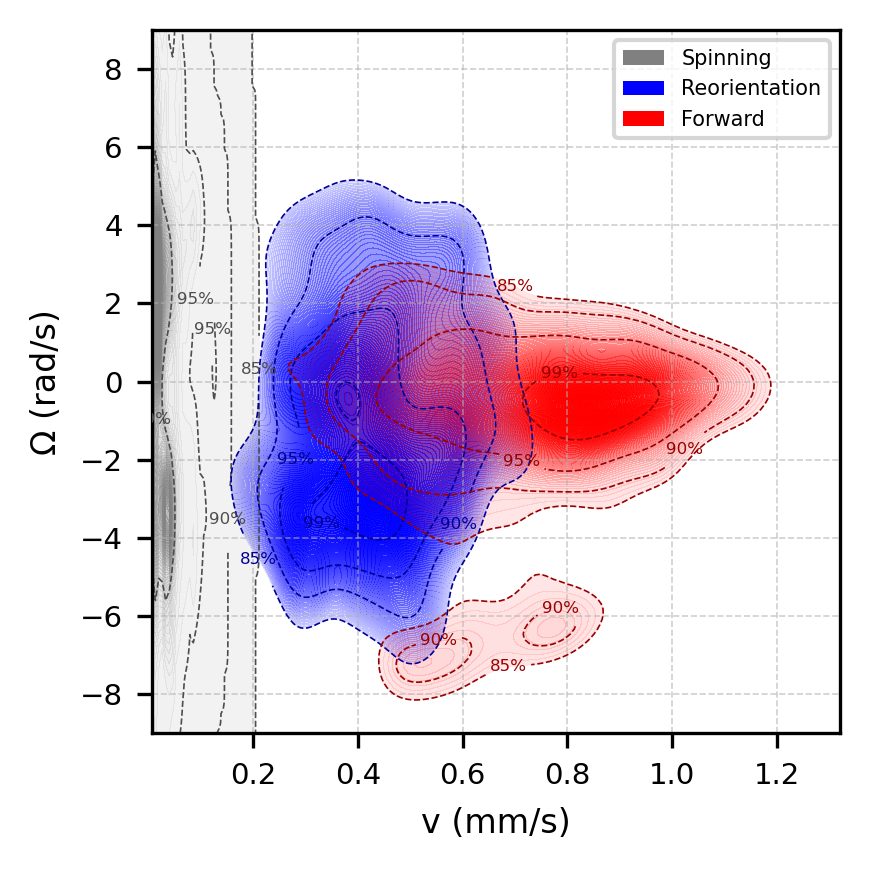

In [7]:
### Creating the plot
plt.figure(dpi=300, figsize=(3, 3))

plot_filled_kde(Z_spinning, 85, color_spinning, label='Spinning')
plot_filled_kde(Z_reorient, 85, color_reorient, label='Reorientation')
plot_filled_kde(Z_forward, 85, color_forward, label='Forward')

plt.xlabel('v (mm/s)', fontsize=8)
plt.ylabel('Ω (rad/s)', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.ylim(-9,9)
plt.tight_layout()



legend_elements = [
    Patch(facecolor=color_spinning, edgecolor='none', label='Spinning'),
    Patch(facecolor=color_reorient, edgecolor='none', label='Reorientation'),
    Patch(facecolor=color_forward, edgecolor='none', label='Forward'),
]

plt.legend(handles=legend_elements, loc='upper right', fontsize=5)

plt.show()
